# EDA on Retail Sales Data

## Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify sales patterns, customer behaviour trends, product performance, and actionable business insights.

## Tools and Technologies

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Analysis Covered

1. Initial Data Inspection
2. Data Cleaning
3. Descriptive Statistics
4. Monthly Sales Trends
5. Quarterly Sales Trends
6. Customer Age Group Analysis
7. Gender Analysis
8. Top 10 Best-Selling Products
9. Revenue by Product Category
10. Correlation Analysis
11. Additional Visualization
12. Key Findings and Business Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../dataset/retail_sales_dataset.csv")

In [4]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

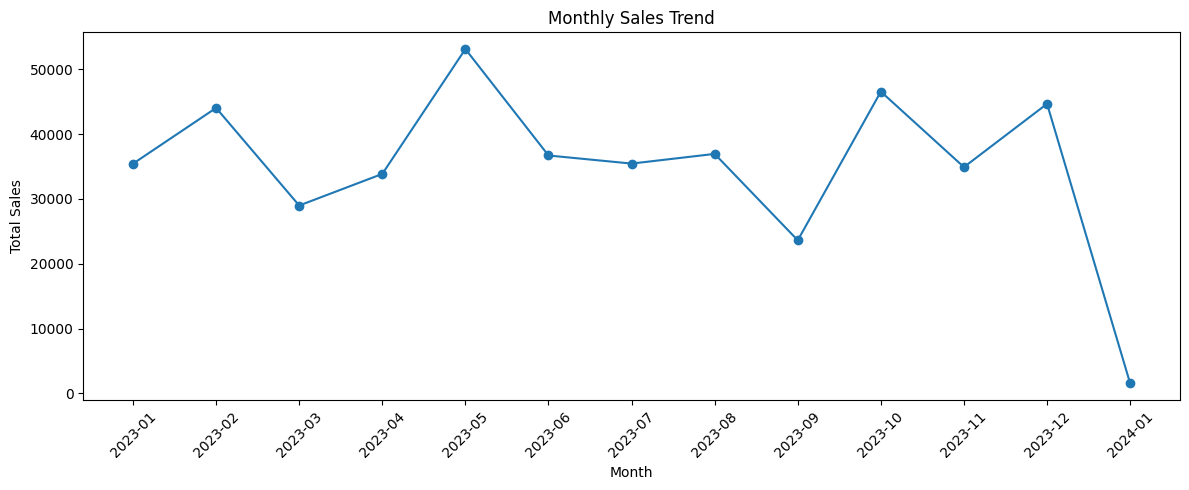

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The monthly sales trend shows how total sales changed over time. The chart helps identify months with relatively higher or lower sales and provides an overall view of sales patterns.

In [12]:
quarterly_sales = df.groupby(
    df['Date'].dt.to_period('Q')
)['Total Amount'].sum()

quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

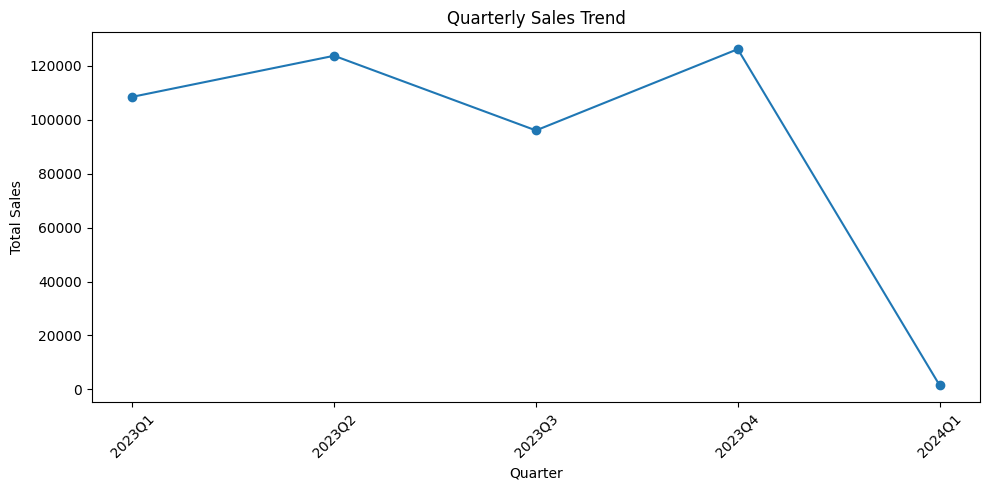

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(quarterly_sales.index.astype(str), quarterly_sales.values, marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The quarterly sales trend shows how total sales changed across different quarters. It helps identify quarters with relatively higher or lower sales performance.

In [14]:
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['Under 18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels
)

age_group_counts = df['Age Group'].value_counts().sort_index()

age_group_counts

Age Group
Under 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56-65       195
65+           0
Name: count, dtype: int64

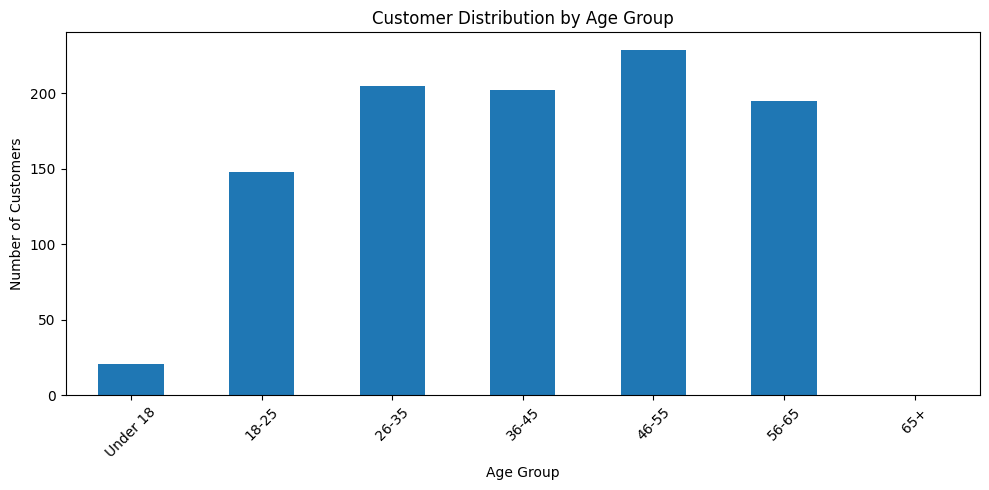

In [15]:
plt.figure(figsize=(10, 5))

age_group_counts.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The age-group distribution shows the number of customers belonging to different age ranges. This helps identify the major customer age groups represented in the retail dataset.

In [16]:
gender_counts = df['Gender'].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

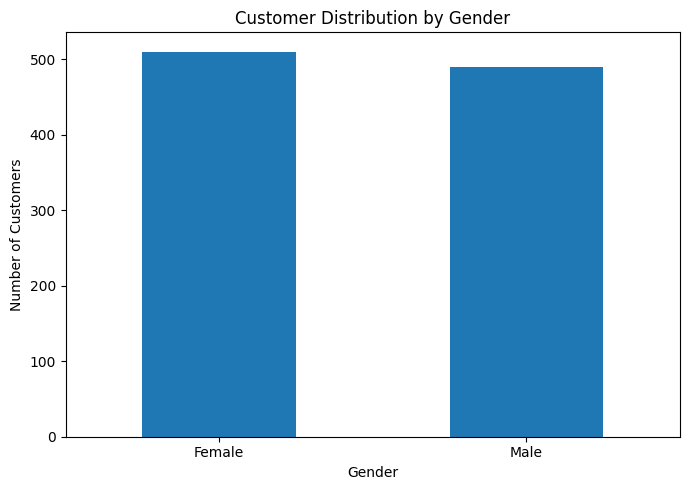

In [17]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The gender distribution chart shows the number of customers in each gender category. This provides an overview of the gender composition of the customers in the dataset.

In [18]:
top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

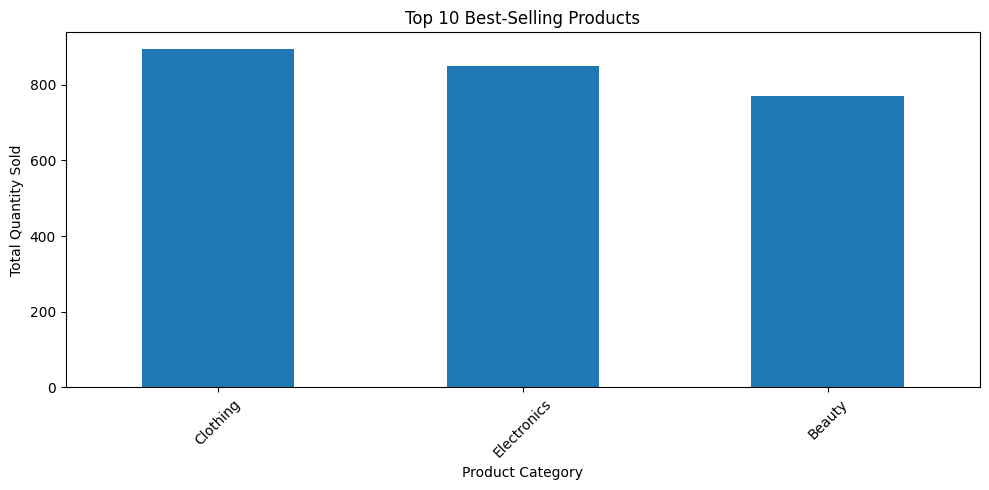

In [19]:
plt.figure(figsize=(10, 5))

top_products.plot(kind='bar')

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The chart shows the top 10 product categories based on total quantity sold. Categories with higher quantities indicate stronger sales volume and can help businesses identify products with greater customer demand.

In [20]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

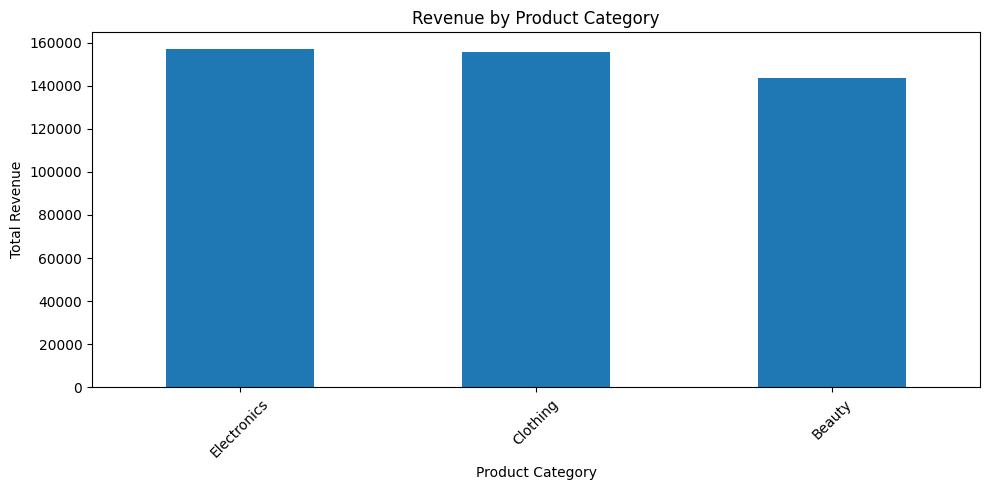

In [21]:
plt.figure(figsize=(10, 5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The chart compares total revenue generated by each product category. It helps identify which categories contribute more to overall revenue.

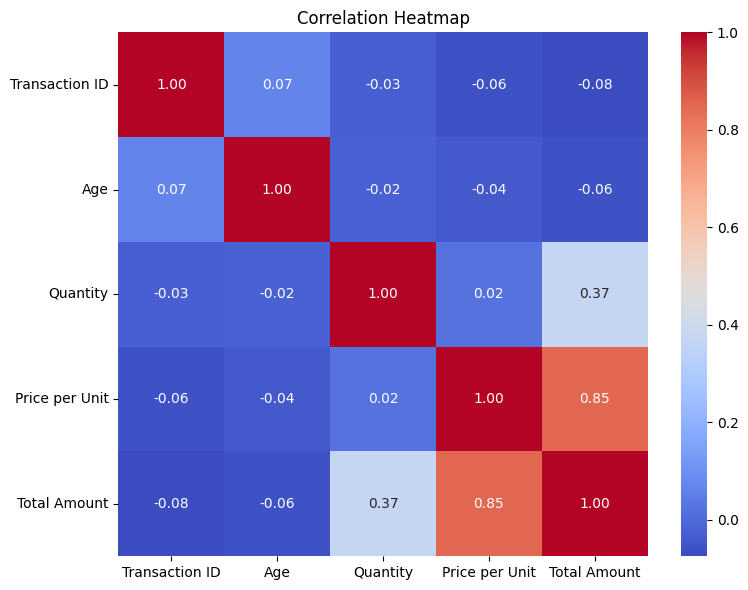

In [22]:
plt.figure(figsize=(8, 6))

correlation = df.select_dtypes(include='number').corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

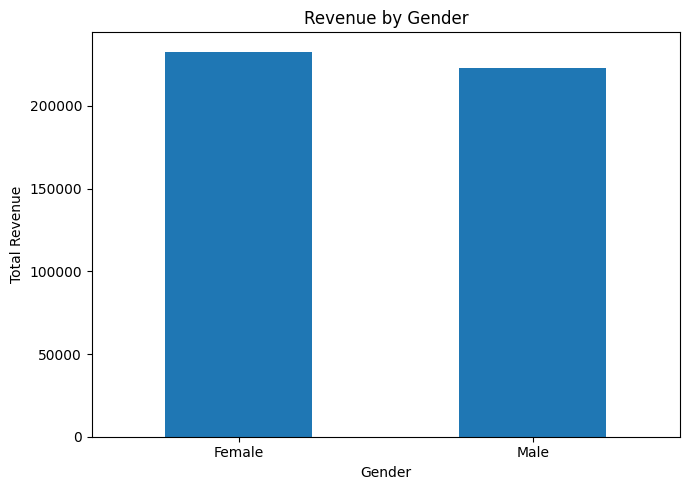

In [23]:
gender_revenue = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(7, 5))

gender_revenue.plot(kind='bar')

plt.title('Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The chart compares total revenue generated by different gender groups. It helps understand the revenue contribution of each customer gender group and can support customer-focused marketing decisions.

## Key Findings

- Monthly sales show variations in revenue across different months.
- Quarterly sales help identify periods with relatively higher and lower sales performance.
- The age-group analysis shows the distribution of customers across different age ranges.
- The gender analysis shows the composition of customers by gender.
- The top-selling product categories indicate areas with higher sales volume.
- Revenue by product category shows which categories contribute more to total revenue.
- The correlation heatmap helps identify relationships among the numerical variables.
- Revenue by gender provides an additional view of customer revenue contribution.

## Business Recommendations

1. **Focus on high-performing product categories:**  
   Allocate sufficient inventory and marketing resources to categories with higher sales volume and revenue contribution.

2. **Plan marketing campaigns around sales trends:**  
   Use monthly and quarterly sales patterns to plan promotions, discounts, and inventory levels during periods of changing demand.

3. **Use customer demographics for targeted marketing:**  
   Customer age-group and gender distribution can be used to design more relevant marketing campaigns and product offers.

4. **Monitor low-performing categories:**  
   Categories with relatively lower sales or revenue should be reviewed to identify opportunities for pricing changes, promotions, or product improvements.

5. **Use data-driven inventory planning:**  
   Sales quantity trends can help businesses maintain appropriate stock levels and reduce the risk of overstocking or stock shortages.

## Conclusion

This exploratory data analysis provided an overview of retail sales performance, customer characteristics, product demand, and revenue patterns. The analysis covered monthly and quarterly sales trends, customer age and gender distribution, best-selling product categories, revenue by category, and relationships between numerical variables.

The insights from this analysis can help businesses make data-driven decisions related to marketing, inventory planning, product performance, and customer targeting.

In [24]:
df.to_csv("../output/retail_sales_cleaned.csv", index=False)

In [25]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Age Group           0
dtype: int64

Duplicate rows:
0
